# NSW Energy Demand & Grid Behaviour — Exploratory Data Analysis

**Dataset:** Merged 10-minute interval dataset containing electricity demand, pricing, weather conditions, holiday indicators, economic metrics, and rooftop solar generation data for New South Wales, Australia.

---
## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e8e8e8',
    'grid.linewidth': 0.6,
})

ModuleNotFoundError: No module named 'numpy'

---
## 2. Load & Inspect

In [2]:
df = pd.read_csv(r"/Users/yash/Documents/Uni Assignments/CODE files/Stats/Assessment_task2/data/dataset.csv")
print(df.shape)
df.head()

(29769, 18)


,DATE_TIME,TOTAL_DEMAND,RRP,PUBLIC_HOLIDAY,SCHOOL_HOLIDAY,TEMPERATURE,DWPC,HUMIDITY,APPARENT_TEMP,WIND_SPEED,CLOUD_COVER,CASH_RATE,HOUSEHOLD_SPEND,SPEND_GROWTH,CONF_IDX,NSW_POPULATION,ROOFTOP_SOLAR_MW,GROSS_DEMAND_MW
0,2022-01-01 00:00:00,7206.03,124.86,True,True,23.0,16.0,64.69,23.0,27.780,2.0,0.1,18099.6,-16.0,101.4,8110610,0.0,7206.03
1,2022-01-01 00:10:00,7174.26,126.02,True,True,23.0,16.0,64.69,23.0,25.928,2.0,0.1,18099.6,-16.0,101.4,8110665,0.0,7174.26
2,2022-01-01 00:20:00,7065.84,113.54,True,True,23.0,16.0,64.69,23.0,24.076,2.0,0.1,18099.6,-16.0,101.4,8110720,0.0,7065.84
3,2022-01-01 00:30:00,6988.47,124.06,True,True,23.0,16.0,64.69,23.0,22.224,2.0,0.1,18099.6,-16.0,101.4,8110775,0.0,6988.47
4,2022-01-01 00:30:00,6988.47,124.06,True,True,23.0,16.0,64.69,23.0,22.224,2.0,0.1,18099.6,-16.0,101.4,8110775,0.0,6988.47


In [3]:
df.dtypes

DATE_TIME               str
TOTAL_DEMAND        float64
RRP                 float64
PUBLIC_HOLIDAY         bool
SCHOOL_HOLIDAY         bool
TEMPERATURE         float64
DWPC                float64
HUMIDITY            float64
APPARENT_TEMP       float64
WIND_SPEED          float64
CLOUD_COVER         float64
CASH_RATE           float64
HOUSEHOLD_SPEND     float64
SPEND_GROWTH        float64
 CONF_IDX           float64
NSW_POPULATION        int64
ROOFTOP_SOLAR_MW    float64
GROSS_DEMAND_MW     float64
dtype: object

In [4]:
# missing values
missing = df.isnull().sum()
print(missing[missing > 0].to_string() if missing.any() else 'No missing values')

No missing values


In [5]:
# duplicates — confirmed in raw data (e.g. 2022-01-01 00:30:00 appears twice)
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 3104


In [6]:
df.describe().round(2)

,TOTAL_DEMAND,RRP,TEMPERATURE,DWPC,HUMIDITY,APPARENT_TEMP,WIND_SPEED,CLOUD_COVER,CASH_RATE,HOUSEHOLD_SPEND,SPEND_GROWTH,CONF_IDX,NSW_POPULATION,ROOFTOP_SOLAR_MW,GROSS_DEMAND_MW
count,29769.00,29769.00,29769.00,29769.00,29769.00,29769.00,29769.00,29769.00,29769.00,29769.00,29769.00,29769.00,29769.00,29769.00,29769.00
mean,7437.37,80.32,23.29,17.85,73.12,23.43,22.57,4.26,3.10,21869.87,-12.68,88.30,8477011.91,1155.18,8592.55
std,1265.34,297.55,3.12,2.48,13.73,3.34,10.94,2.64,1.57,2042.42,1.87,6.74,141732.89,1479.87,1750.89
min,4050.18,-999.99,15.00,5.00,12.50,15.00,0.00,0.00,0.10,17983.30,-16.00,78.70,8110610.00,0.00,5660.32
25%,6548.39,52.92,21.00,16.00,64.26,21.00,13.58,2.00,3.10,21629.70,-13.40,84.00,8390295.00,0.00,7169.99
50%,7274.56,72.68,23.00,18.00,73.61,23.00,21.61,6.00,3.60,22511.80,-11.70,86.60,8542276.00,348.24,8441.65
75%,8115.03,92.01,25.00,20.00,83.21,25.00,29.63,6.00,4.35,23055.70,-11.50,86.90,8592524.00,2101.02,9671.60
max,13137.47,17500.00,42.00,24.00,100.00,42.29,77.78,8.00,4.35,24053.60,-0.60,101.40,8592524.00,6509.90,15885.70


### Key Takeaways
- `RRP` varies a lot across the dataset, including some large price spikes, which is fairly common in the National Electricity Market during periods of high demand or grid pressure.
- `ROOFTOP_SOLAR_MW` falls to 0 overnight and rises through the daytime as rooftop solar generation increases.
- `TOTAL_DEMAND` and `GROSS_DEMAND_MW` are almost identical at night, but start to diverge during the day when rooftop solar begins offsetting part of the grid demand.

---
## 3. Preprocessing & Feature Engineering

In [7]:
# datetime
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])

# drop exact duplicates
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate rows → {len(df):,} remaining")

df = df.sort_values('DATE_TIME').reset_index(drop=True)

Removed 3104 duplicate rows → 26,665 remaining


In [8]:
# cast boolean columns — loaded as string 'True'/'False'
for col in ['PUBLIC_HOLIDAY', 'SCHOOL_HOLIDAY']:
    df[col] = df[col].map({'True': 1, 'False': 0, True: 1, False: 0}).astype(int)

df[['PUBLIC_HOLIDAY', 'SCHOOL_HOLIDAY']].value_counts()

PUBLIC_HOLIDAY  SCHOOL_HOLIDAY
0               1                 21672
                0                  2929
1               1                  2064
Name: count, dtype: int64

In [9]:
# drop rows missing core columns only
core_cols = ['TOTAL_DEMAND', 'GROSS_DEMAND_MW', 'TEMPERATURE', 'ROOFTOP_SOLAR_MW']
before = len(df)
df = df.dropna(subset=core_cols).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with nulls in core columns")

Dropped 0 rows with nulls in core columns


In [10]:
# time features
df['hour']       = df['DATE_TIME'].dt.hour
df['minute']     = df['DATE_TIME'].dt.minute
df['dayofweek']  = df['DATE_TIME'].dt.dayofweek   # 0=Mon, 6=Sun
df['month']      = df['DATE_TIME'].dt.month
df['year']       = df['DATE_TIME'].dt.year
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

# day type — holiday takes priority over weekend
conditions = [
    df['PUBLIC_HOLIDAY'] == 1,
    df['is_weekend'] == 1,
]
df['day_type'] = np.select(conditions, ['Holiday', 'Weekend'], default='Weekday')

df[['DATE_TIME', 'hour', 'dayofweek', 'day_type', 'PUBLIC_HOLIDAY']].head(8)

,DATE_TIME,hour,dayofweek,day_type,PUBLIC_HOLIDAY
0,2022-01-01 00:00:00,0,5,Holiday,1
1,2022-01-01 00:10:00,0,5,Holiday,1
2,2022-01-01 00:20:00,0,5,Holiday,1
3,2022-01-01 00:30:00,0,5,Holiday,1
4,2022-01-01 00:40:00,0,5,Holiday,1
5,2022-01-01 00:50:00,0,5,Holiday,1
6,2022-01-01 01:00:00,1,5,Holiday,1
7,2022-01-01 01:10:00,1,5,Holiday,1


In [11]:
# temperature bins (2°C) for RQ1
t_min = int(df['TEMPERATURE'].min() // 2) * 2
t_max = int(df['TEMPERATURE'].max() // 2) * 2 + 4
df['temp_bin'] = pd.cut(df['TEMPERATURE'], bins=range(t_min, t_max, 2), right=False)

print(f"Temperature range : {df['TEMPERATURE'].min():.1f}°C – {df['TEMPERATURE'].max():.1f}°C")
print(f"Date range        : {df['DATE_TIME'].min().date()} → {df['DATE_TIME'].max().date()}")
print(f"\nDay type counts:\n{df['day_type'].value_counts()}")

Temperature range : 15.0°C – 42.0°C
Date range        : 2022-01-01 → 2026-02-01

Day type counts:
day_type
Weekday    17375
Weekend     7226
Holiday     2064
Name: count, dtype: int64


---
## 4. Research Questions

---
### RQ1 — How does temperature influence electricity demand, and does the relationship change under extreme weather?

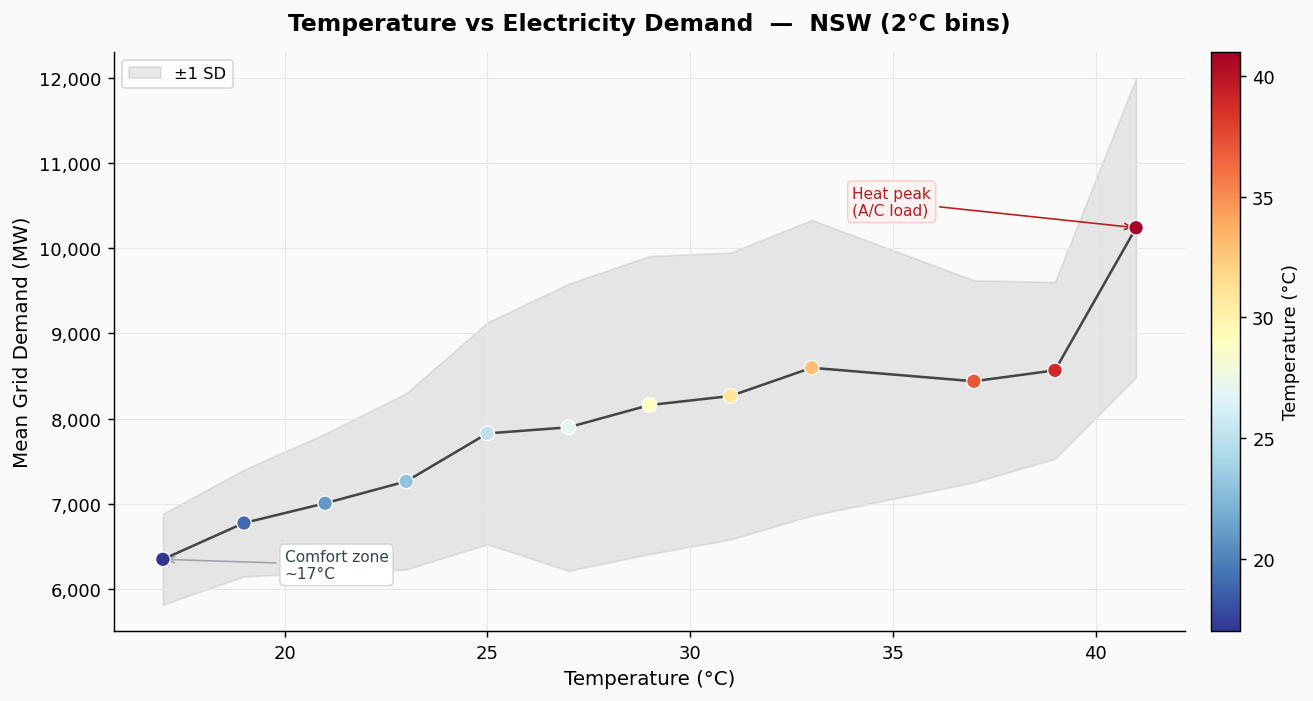

In [12]:
# mean ± SD demand per 2°C bin; drop sparse bins
temp_demand = (
    df.groupby('temp_bin', observed=True)['TOTAL_DEMAND']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
temp_demand['temp_mid'] = temp_demand['temp_bin'].apply(lambda x: x.mid)
temp_demand = temp_demand[temp_demand['count'] >= 50].copy()

cmap = plt.cm.RdYlBu_r
norm = plt.Normalize(temp_demand['temp_mid'].min(), temp_demand['temp_mid'].max())

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

# ±1 SD band
ax.fill_between(
    temp_demand['temp_mid'],
    temp_demand['mean'] - temp_demand['std'],
    temp_demand['mean'] + temp_demand['std'],
    alpha=0.12, color='#555555', label='±1 SD'
)

# connecting line
ax.plot(temp_demand['temp_mid'], temp_demand['mean'],
        color='#444444', lw=1.4, zorder=3)

# coloured scatter
sc = ax.scatter(
    temp_demand['temp_mid'], temp_demand['mean'],
    c=temp_demand['temp_mid'], cmap=cmap, norm=norm,
    s=65, zorder=4, edgecolors='white', linewidths=0.7
)
plt.colorbar(sc, ax=ax, label='Temperature (°C)', pad=0.02)

# comfort zone trough
trough = temp_demand.loc[temp_demand['mean'].idxmin()]
ax.annotate(
    f'Comfort zone\n~{trough["temp_mid"]:.0f}°C',
    xy=(trough['temp_mid'], trough['mean']),
    xytext=(trough['temp_mid'] + 3, trough['mean'] - 220),
    fontsize=8.5, color='#374151',
    arrowprops=dict(arrowstyle='->', color='#9CA3AF', lw=0.9),
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#D1D5DB', lw=0.8)
)

# cold peak
cold_side = temp_demand[temp_demand['temp_mid'] < trough['temp_mid']]
if len(cold_side):
    cold_peak = cold_side.loc[cold_side['mean'].idxmax()]
    ax.annotate(
        'Cold peak\n(heating load)',
        xy=(cold_peak['temp_mid'], cold_peak['mean']),
        xytext=(cold_peak['temp_mid'] + 2.5, cold_peak['mean'] + 200),
        fontsize=8.5, color='#1D4ED8',
        arrowprops=dict(arrowstyle='->', color='#1D4ED8', lw=0.9),
        bbox=dict(boxstyle='round,pad=0.3', fc='#EFF6FF', ec='#BFDBFE', lw=0.8)
    )

# heat peak
hot_side = temp_demand[temp_demand['temp_mid'] > trough['temp_mid']]
if len(hot_side):
    hot_peak = hot_side.loc[hot_side['mean'].idxmax()]
    ax.annotate(
        'Heat peak\n(A/C load)',
        xy=(hot_peak['temp_mid'], hot_peak['mean']),
        xytext=(hot_peak['temp_mid'] - 7, hot_peak['mean'] + 150),
        fontsize=8.5, color='#B91C1C',
        arrowprops=dict(arrowstyle='->', color='#B91C1C', lw=0.9),
        bbox=dict(boxstyle='round,pad=0.3', fc='#FEF2F2', ec='#FECACA', lw=0.8)
    )

ax.set_xlabel('Temperature (°C)', fontsize=11)
ax.set_ylabel('Mean Grid Demand (MW)', fontsize=11)
ax.set_title('Temperature vs Electricity Demand  —  NSW (2°C bins)', fontsize=13, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=9, framealpha=0.7)

plt.tight_layout()
plt.savefig('rq1_temp_vs_demand.png', bbox_inches='tight')
plt.show()

**Observation:** Demand follows a U-shape across temperature - lowest around 18–22°C and rising at both extremes. The hot-end increase is steeper, driven by air-conditioning load; NSW has high A/C penetration so heat events hit the grid hard. The cold-end rise is shallower since space heating in NSW is less electrified. The wider SD band at extremes suggests demand becomes harder to predict during unusual weather — not just higher, but more variable.

---
### RQ2 — How do demand patterns vary between weekdays, weekends, and holidays across the day?

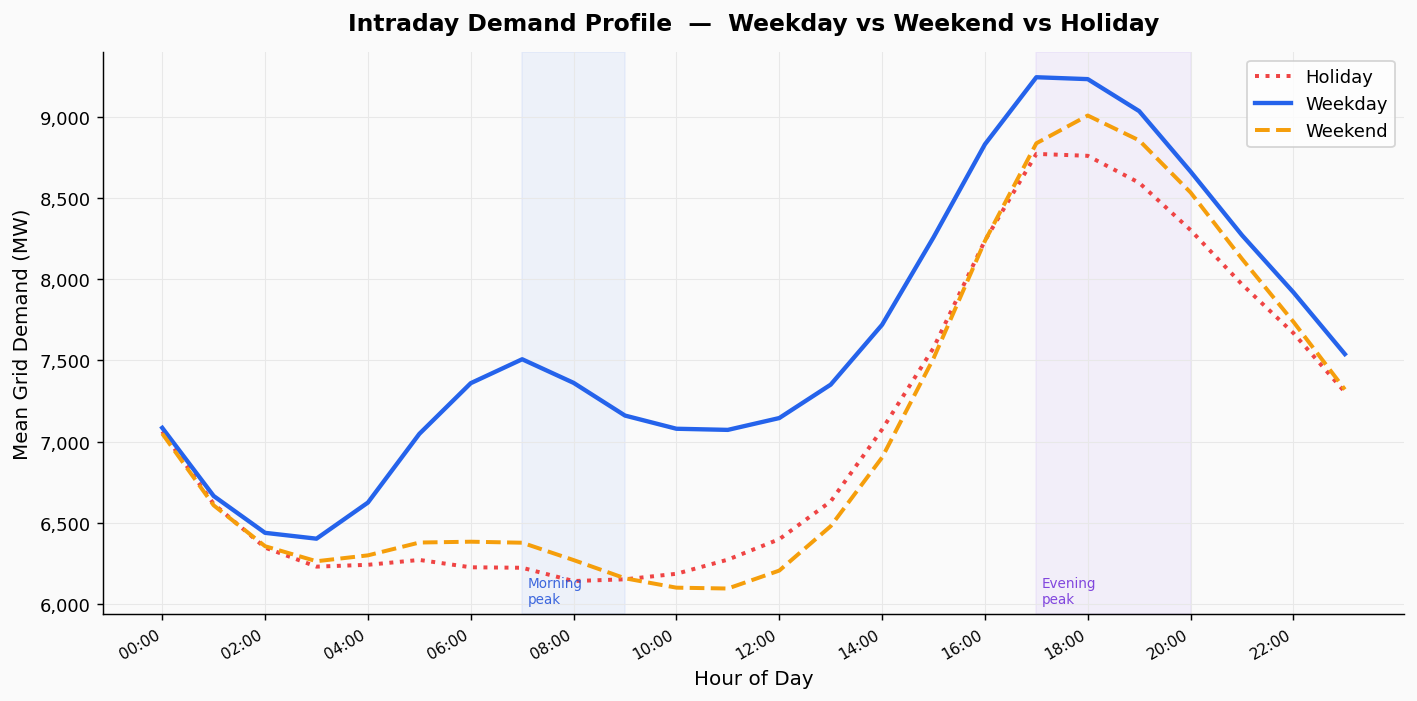

In [13]:
hourly = (
    df.groupby(['day_type', 'hour'])['TOTAL_DEMAND']
    .mean()
    .reset_index()
)

palette    = {'Weekday': '#2563EB', 'Weekend': '#F59E0B', 'Holiday': '#EF4444'}
linestyles = {'Weekday': '-',       'Weekend': '--',       'Holiday': ':'}
linewidths = {'Weekday': 2.4,       'Weekend': 2.2,        'Holiday': 2.2}

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

for dt, grp in hourly.groupby('day_type'):
    ax.plot(
        grp['hour'], grp['TOTAL_DEMAND'],
        color=palette[dt], lw=linewidths[dt],
        ls=linestyles[dt], label=dt, zorder=3
    )

# shade peak windows
ax.axvspan(7, 9,   alpha=0.06, color='#2563EB')
ax.axvspan(17, 20, alpha=0.06, color='#7C3AED')

# re-draw y limits before adding text so get_ylim() is stable
ax.autoscale_view()
ymin = ax.get_ylim()[0]
ax.text(7.1,  ymin + 50, 'Morning\npeak', fontsize=7.5, color='#1D4ED8', va='bottom', alpha=0.85)
ax.text(17.1, ymin + 50, 'Evening\npeak', fontsize=7.5, color='#6D28D9', va='bottom', alpha=0.85)

ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=30, ha='right', fontsize=8.5)
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Mean Grid Demand (MW)', fontsize=11)
ax.set_title('Intraday Demand Profile  —  Weekday vs Weekend vs Holiday', fontsize=13, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10, framealpha=0.8)

plt.tight_layout()
plt.savefig('rq2_intraday_demand.png', bbox_inches='tight')
plt.show()

**Observation:** The morning spike (7–9am) on weekdays is almost entirely commercial and industrial — it disappears on weekends and holidays. The evening peak (5–8pm) is present across all day types but is largest on weekdays when it stacks residential load on top of an already-loaded grid. Weekends ramp up later and plateau lower. Holidays behave like weekends, sometimes slightly below — consistent with near-zero business activity.

---
### RQ3 — How does rooftop solar affect grid electricity demand throughout the day?

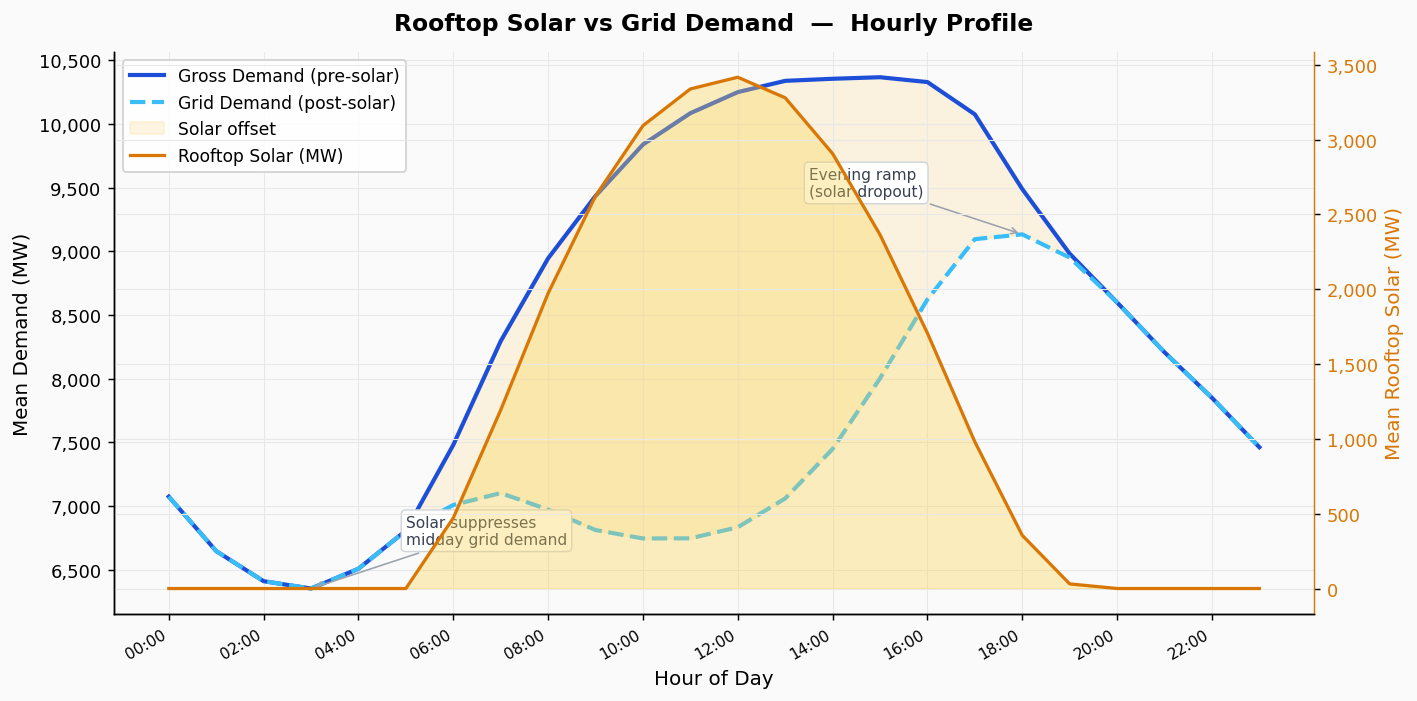

In [14]:
solar_hourly = (
    df.groupby('hour')[['GROSS_DEMAND_MW', 'TOTAL_DEMAND', 'ROOFTOP_SOLAR_MW']]
    .mean()
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor('#FAFAFA')
ax1.set_facecolor('#FAFAFA')

# demand lines
ax1.plot(solar_hourly['hour'], solar_hourly['GROSS_DEMAND_MW'],
         color='#1D4ED8', lw=2.3, label='Gross Demand (pre-solar)', zorder=3)
ax1.plot(solar_hourly['hour'], solar_hourly['TOTAL_DEMAND'],
         color='#38BDF8', lw=2.3, ls='--', label='Grid Demand (post-solar)', zorder=3)

# solar offset gap
ax1.fill_between(
    solar_hourly['hour'],
    solar_hourly['TOTAL_DEMAND'],
    solar_hourly['GROSS_DEMAND_MW'],
    alpha=0.13, color='#FBBF24', label='Solar offset'
)

ax1.set_xlabel('Hour of Day', fontsize=11)
ax1.set_ylabel('Mean Demand (MW)', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# rooftop solar on secondary axis
ax2 = ax1.twinx()
ax2.fill_between(solar_hourly['hour'], 0, solar_hourly['ROOFTOP_SOLAR_MW'],
                 color='#FCD34D', alpha=0.35)
ax2.plot(solar_hourly['hour'], solar_hourly['ROOFTOP_SOLAR_MW'],
         color='#D97706', lw=1.8)
ax2.set_ylabel('Mean Rooftop Solar (MW)', fontsize=11, color='#D97706')
ax2.tick_params(axis='y', labelcolor='#D97706')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color('#D97706')
ax2.spines['top'].set_visible(False)

# annotate duck curve trough
trough_idx = solar_hourly['TOTAL_DEMAND'].idxmin()
trough_hr  = solar_hourly.loc[trough_idx, 'hour']
trough_val = solar_hourly.loc[trough_idx, 'TOTAL_DEMAND']
ax1.annotate(
    'Solar suppresses\nmidday grid demand',
    xy=(trough_hr, trough_val),
    xytext=(trough_hr + 2, trough_val + 350),
    fontsize=8.5, color='#374151',
    arrowprops=dict(arrowstyle='->', color='#9CA3AF', lw=0.9),
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#D1D5DB', lw=0.8)
)

# annotate evening ramp
ramp_hr  = 18
ramp_val = solar_hourly.loc[solar_hourly['hour'] == ramp_hr, 'TOTAL_DEMAND'].values[0]
ax1.annotate(
    'Evening ramp\n(solar dropout)',
    xy=(ramp_hr, ramp_val),
    xytext=(ramp_hr - 4.5, ramp_val + 300),
    fontsize=8.5, color='#374151',
    arrowprops=dict(arrowstyle='->', color='#9CA3AF', lw=0.9),
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#D1D5DB', lw=0.8)
)

ax1.set_xticks(range(0, 24, 2))
ax1.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=30, ha='right', fontsize=8.5)
ax1.set_title('Rooftop Solar vs Grid Demand  —  Hourly Profile', fontsize=13, fontweight='bold', pad=12)

# unified legend
lines1, labels1 = ax1.get_legend_handles_labels()
solar_line = Line2D([0], [0], color='#D97706', lw=1.8, label='Rooftop Solar (MW)')
ax1.legend(handles=lines1 + [solar_line], fontsize=9.5, framealpha=0.85, loc='upper left')

plt.tight_layout()
plt.savefig('rq3_solar_vs_demand.png', bbox_inches='tight')
plt.show()

**Observation:** Rooftop solar significantly reduces grid demand during the middle of the day, creating the visible gap between gross demand and actual grid demand. As solar generation drops later in the afternoon and households move into evening usage, grid demand rises sharply again. This creates the classic “duck curve” pattern — a midday dip followed by a steep evening ramp, which can be challenging for grid operators to manage.
